In [1]:
%pip install tensorflow==2.16.2


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np 
from tensorflow.keras.datasets import mnist 

# Load the dataset 
(x_train, _), (x_test, _) = mnist.load_data() 

# Normalize the pixel values 
x_train = x_train.astype('float32') / 255. 
x_test = x_test.astype('float32') / 255. 

# Flatten the images 
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) 
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) 

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Building the Autoencoder Model

In [3]:
from tensorflow.keras.models import Model 
# Importa a classe Model → usada para criar modelos personalizados (não sequenciais)

from tensorflow.keras.layers import Input, Dense 
# Importa:
# Input → define a entrada do modelo
# Dense → camada totalmente conectada (rede neural clássica)

# Encoder 
input_layer = Input(shape=(784,)) 
# Define a entrada do modelo com 784 valores
# (ex: imagem 28x28 achatada → 28*28 = 784)

encoded = Dense(64, activation='relu')(input_layer) 
# Primeira camada do encoder:
# reduz de 784 → 64 dimensões
# activation='relu' → ajuda a aprender padrões não lineares

# Bottleneck 
bottleneck = Dense(32, activation='relu')(encoded) 
# Camada mais importante (bottleneck):
# reduz ainda mais → 64 → 32
# aqui o modelo "resume" a informação essencial

# Decoder 
decoded = Dense(64, activation='relu')(bottleneck) 
# Começa a reconstrução:
# 32 → 64 dimensões

output_layer = Dense(784, activation='sigmoid')(decoded) 
# Reconstrói o dado original:
# 64 → 784
# sigmoid → garante saída entre 0 e 1 (ideal para imagens normalizadas)

# Autoencoder model 
autoencoder = Model(input_layer, output_layer) 
# Cria o modelo completo:
# entrada → saída reconstruída

# Compile the model 
autoencoder.compile(optimizer='adam', loss='binary_crossentropy') 
# Define como o modelo aprende:
# optimizer='adam' → ajusta os pesos automaticamente
# loss='binary_crossentropy' → mede erro entre entrada e reconstrução

# Summary of the model 
autoencoder.summary() 
# Mostra a arquitetura do modelo (camadas, parâmetros, etc.)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,392 (411.69 KB)

 Trainable params: 105,392 (411.69 KB)

 Non-trainable params: 0 (0.00 B)

Training the Autoencoder

In [4]:
autoencoder.fit(
    x_train, x_train,  
    epochs=25,  
    batch_size=256,  
    shuffle=True,  
    validation_data=(x_test, x_test)
)

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2583 - val_loss: 0.1774
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1612 - val_loss: 0.1460
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1386 - val_loss: 0.1297
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1264 - val_loss: 0.1205
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1193 - val_loss: 0.1152
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1150 - val_loss: 0.1115
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1115 - val_loss: 0.1085
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1089 - val_loss: 0.1063
Epoch 9/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1067 - val_loss: 0.1041
Epoch 10/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1048 - val_loss: 0.1026
Epoch 11/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1035 - val_loss: 0.1014
Epoch 12/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

Evaluating the Autoencoder

In [5]:
%pip install matplotlib==3.9.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 8.2 MB/s  0:00:01m0:00:0100:01
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.9.1
    Uninstalling matplotlib-3.9.1:
      Successfully uninstalled matplotlib-3.9.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
plotnine 0.14.5 requires pandas>=2.2.0, but you have pandas 2.1.4 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step


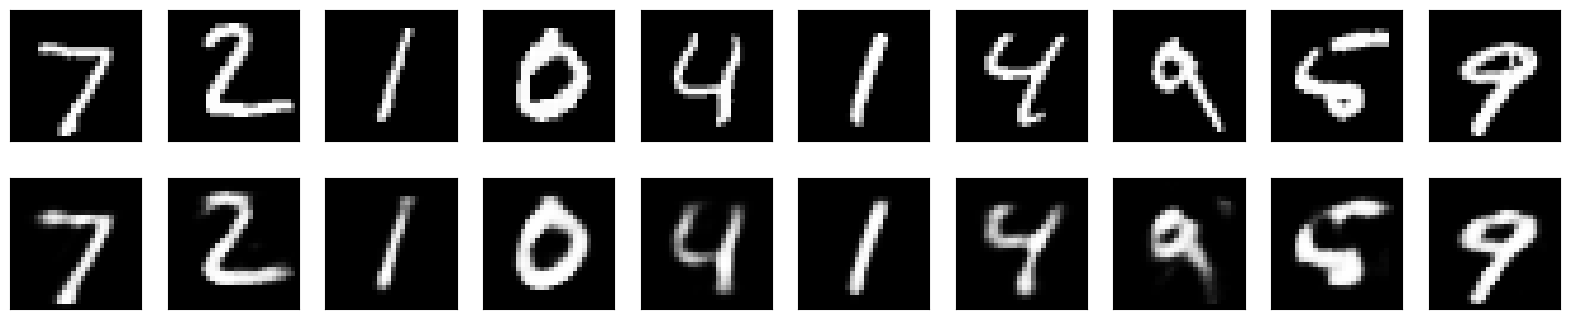

In [7]:
import matplotlib.pyplot as plt  # Biblioteca para visualizar imagens

reconstructed = autoencoder.predict(x_test)  # Passa os dados de teste pelo modelo e gera as reconstruções

n = 10  # Número de imagens que serão exibidas

plt.figure(figsize=(20, 4))  # Cria uma figura grande para mostrar as imagens

for i in range(n):  # Loop para percorrer as primeiras n imagens

    ax = plt.subplot(2, n, i + 1)  # Cria um grid com 2 linhas e n colunas (linha de cima = original)

    plt.imshow(x_test[i].reshape(28, 28))  # Converte o vetor em imagem 28x28 e exibe
    plt.gray()  # Define escala de cinza

    ax.get_xaxis().set_visible(False)  # Remove eixo X
    ax.get_yaxis().set_visible(False)  # Remove eixo Y

    ax = plt.subplot(2, n, i + 1 + n)  # Segunda linha do grid (imagens reconstruídas)

    plt.imshow(reconstructed[i].reshape(28, 28))  # Exibe a imagem reconstruída pelo modelo
    plt.gray()  # Mantém escala de cinza

    ax.get_xaxis().set_visible(False)  # Remove eixo X
    ax.get_yaxis().set_visible(False)  # Remove eixo Y

plt.show()  # Mostra todas as imagens na tela

Fine-Tuning the Autoencoder

Fine-Tuning the Autoencoder

In [8]:
# Freeze all layers of the autoencoder
for layer in autoencoder.layers:  
    # Percorre todas as camadas do modelo autoencoder

    layer.trainable = False  
    # Define que a camada NÃO será treinada (pesos não serão atualizados)

In [9]:
# Check trainable status of each layer
for i, layer in enumerate(autoencoder.layers):  
    # enumerate percorre todas as camadas do modelo
    # i = índice da camada (0, 1, 2...)
    # layer = objeto da camada em si

    print(f"Layer {i}: {layer.name}, Trainable = {layer.trainable}")  
    # Exibe:
    # - número da camada
    # - nome da camada
    # - se ela está treinável (True) ou congelada (False)

Layer 0: input_layer, Trainable = False
Layer 1: dense, Trainable = False
Layer 2: dense_1, Trainable = False
Layer 3: dense_2, Trainable = False
Layer 4: dense_3, Trainable = False


In [10]:
# Unfreeze the top layers of the encoder
for layer in autoencoder.layers[-4:]:  # Seleciona as últimas 4 camadas do modelo
    layer.trainable = True  # Define essas camadas como treináveis (descongela)

# Compile the model again
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')  # Recompila o modelo para aplicar as mudanças de trainable

# Train the model again
autoencoder.fit(x_train, x_train,  # Entrada = saída (autoencoder aprende reconstrução)
                epochs=10,  # Número de épocas de treino
                batch_size=256,  # Quantidade de amostras por batch
                shuffle=True,  # Embaralha os dados a cada época
                validation_data=(x_test, x_test))  # Usa dados de teste para validação

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0943 - val_loss: 0.0927
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0937 - val_loss: 0.0924
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0934 - val_loss: 0.0922
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0932 - val_loss: 0.0921
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0929 - val_loss: 0.0918
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0927 - val_loss: 0.0915
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0924 - val_loss: 0.0912
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0922 - val_loss: 0.0911
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0920 - val_loss: 0.0908
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0917 - val_loss: 0.0906


Denoising Images with Autoencoder

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1733 - val_loss: 0.1448
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1404 - val_loss: 0.1349
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1334 - val_loss: 0.1301
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1295 - val_loss: 0.1271
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1272 - val_loss: 0.1256
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1258 - val_loss: 0.1247
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1248 - val_loss: 0.1235
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1241 - val_loss: 0.1229
Epoch 9/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1235 - val_loss: 0.1227
Epoch 10/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1230 - val_loss: 0.1229
Epoch 11/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1227 - val_loss: 0.1219
Epoch 12/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/st

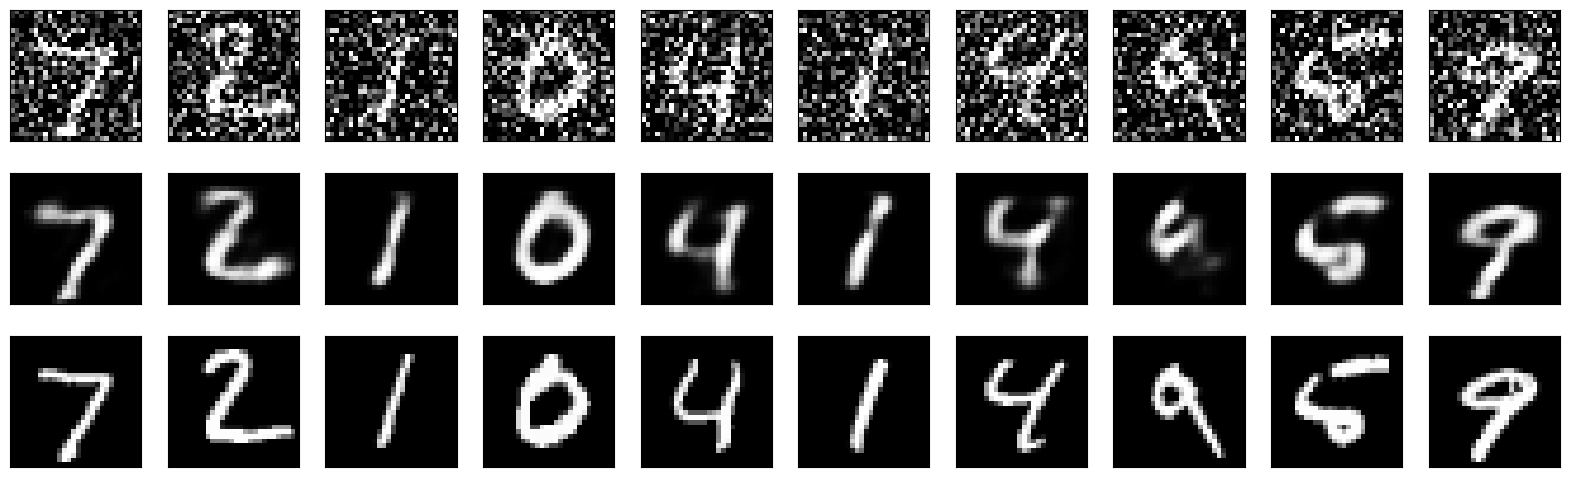

In [11]:
import numpy as np  # Biblioteca para operações numéricas
import matplotlib.pyplot as plt  # Biblioteca para visualização

# Add noise to the data
noise_factor = 0.5  # Intensidade do ruído que será adicionado
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)  # Adiciona ruído gaussiano aos dados de treino
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)  # Adiciona ruído gaussiano aos dados de teste
x_train_noisy = np.clip(x_train_noisy, 0., 1.)  # Garante que os valores fiquem entre 0 e 1
x_test_noisy = np.clip(x_test_noisy, 0., 1.)  # Garante que os valores fiquem entre 0 e 1

# Train the autoencoder with noisy data
autoencoder.fit(
    x_train_noisy, x_train,  # Entrada com ruído, saída limpa (modelo aprende a remover ruído)
    epochs=20,  # Número de épocas de treino
    batch_size=512,  # Quantidade de amostras por batch
    shuffle=True,  # Embaralha os dados a cada época
    validation_data=(x_test_noisy, x_test)  # Validação com dados ruidosos (entrada) e limpos (saída)
)

# Denoise the test images
reconstructed_noisy = autoencoder.predict(x_test_noisy)  # O modelo tenta remover o ruído das imagens de teste

# Visualize the results
n = 10  # Number of digits to display
plt.figure(figsize=(20, 6))  # Define o tamanho da figura
for i in range(n):
    # Display noisy images
    ax = plt.subplot(3, n, i + 1)  # Primeira linha: imagens com ruído
    plt.imshow(x_test_noisy[i].reshape(28, 28))  # Mostra imagem ruidosa
    plt.gray()  # Escala de cinza
    ax.get_xaxis().set_visible(False)  # Remove eixo X
    ax.get_yaxis().set_visible(False)  # Remove eixo Y
    
    # Display denoised images
    ax = plt.subplot(3, n, i + 1 + n)  # Segunda linha: imagens reconstruídas (sem ruído)
    plt.imshow(reconstructed_noisy[i].reshape(28, 28))  # Mostra imagem "limpa" pelo modelo
    plt.gray()  # Escala de cinza
    ax.get_xaxis().set_visible(False)  # Remove eixo X
    ax.get_yaxis().set_visible(False)  # Remove eixo Y

    # Display original images
    ax = plt.subplot(3, n, i + 1 + 2 * n)  # Terceira linha: imagens originais
    plt.imshow(x_test[i].reshape(28, 28))  # Mostra imagem original sem ruído
    plt.gray()  # Escala de cinza
    ax.get_xaxis().set_visible(False)  # Remove eixo X
    ax.get_yaxis().set_visible(False)  # Remove eixo Y

plt.show()  # Exibe todas as imagens